In [1]:
from cellsweep.simulation import simulate_cells
from cellsweep.simulation import simple_simulation
import cellsweep.utils as cs_utils
from cellsweep import denoise_count_matrix #, sparse_em, e_step_numba 
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellsweep_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "debug_sim")

In [2]:
# %load_ext line_profiler

In [3]:
%matplotlib widget

In [4]:
data = simulate_cells(G=10000, N=8000, empty_prob=0.8, alpha=0.03, beta=0.01)

In [5]:
data.uns['marker_sets'].flatten()

array([5094, 4381,  719, 3922, 9355, 6838, 6870, 8177, 1260,  644, 5168,
       5282,   34, 9018, 4879, 1538, 6281,  888, 3084,  529, 6734, 6223,
       6309, 8610, 4540, 7050, 1490, 1734, 9274, 9515, 2048, 5974, 3570,
       7833, 4329, 9587,  828, 4949, 3964, 5660, 7726,  320, 9823, 2711,
       1783, 5322, 8423, 9555, 5868, 1054, 2841, 7089, 1627, 9183, 3338,
       2661, 6674, 2369, 7823, 2649, 7524, 1736, 2310, 3194, 2969, 4776,
       7245, 3189, 3574, 5790, 2564, 9489, 5899, 9971, 3672, 5695, 8109,
       6294, 2210, 8091, 9837, 5184, 5956, 8084, 4588, 1918, 5465, 5857,
       7318, 1466, 9169,  486, 3341, 6941, 9787, 3486, 7254, 9348, 2874,
        963, 8603, 2418, 4223, 1919, 3877, 3935,  190, 5300, 4360, 2358,
       9357, 7062, 1626, 9470, 7164, 4216, 9495, 6947, 9007, 4268,  372,
       2397,  898, 5830,   48, 2547, 9413, 9520, 9002, 2717, 9237, 8049,
       6095, 6616,  290,   16, 9963, 9299, 4142, 1136, 1401, 3256,  348,
        896, 2379, 6131, 2900, 7648, 3474, 4196])

Gene_1844: 64936
Gene_719: 45219
Gene_7833: 22061
Gene_3084: 21586
Gene_3964: 19477
Gene_5168: 19393
Gene_2564: 18337
Gene_5728: 18182
Gene_5660: 17864
Gene_2649: 16687


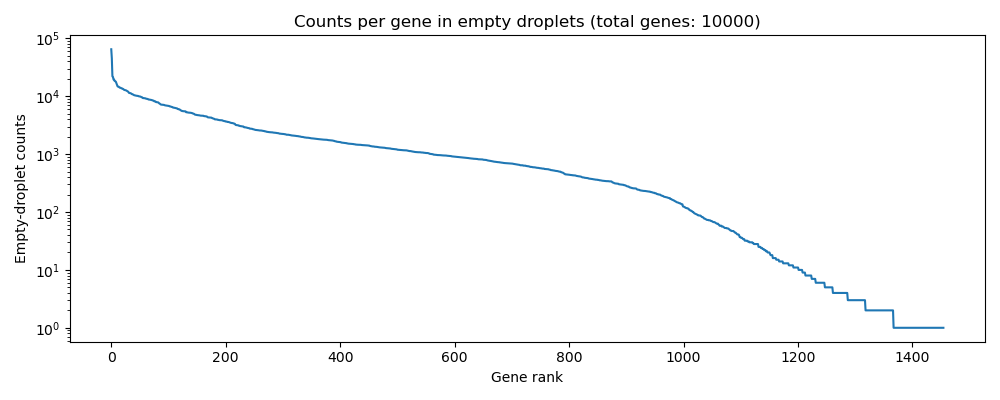

In [6]:
cs_utils.plot_empty_gene_counts(data, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cs_utils.print_top_empty_genes(data, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

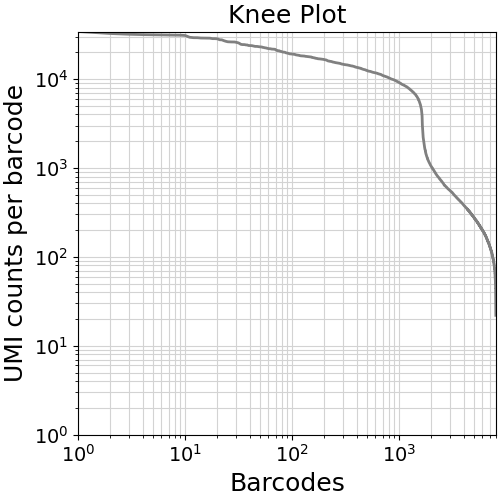

In [7]:
cs_utils.knee_plot(data)

In [8]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellsweep.log")

In [9]:
#%lprun -f e_step_numba denoise_count_matrix(data, max_iter=2, threads=1, adata_out = adata_cellmender_path, log_file = adata_log_path)

In [ ]:
denoised_data = data.copy()
denoise_count_matrix(denoised_data, tol=1e-12, init_alpha = 0.3, verbose=2, threads=8, adata_out = adata_cellmender_path, log_file = adata_log_path)

22:42:51 - INFO - Starting cellsweep denoising at 2026-01-07 22:42:51, cellsweep version 0.1.0
22:42:51 - INFO - Inferring celltype profiles.
22:42:51 - DEBUG - Number of parameters in the cellsweep model: 51,637 (alpha: 1,636, beta: 1, p_k: 50,000)
22:42:51 - INFO - Inferring the gene ambient profile from empty droplets.
22:42:51 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
/Users/mcaskey/Desktop/cellsweep/cellsweep/celltype_ambient.py:595: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.clip(a, log_eps, None))        # (G,)
22:42:51 - INFO - Detected empty droplets based on initial parameters. New empties detected: 0
22:42:51 - INFO - Performing Sparse EM with 8 Numba thread(s)


Logging to /Users/mcaskey/Desktop/cellsweep/notebooks/output/debug_sim/cellsweep.log


22:42:52 - INFO - EM Iter   1: ll=-15531.463 min_alpha=0.1702 mean_alpha=0.2387 median_alpha=0.2402 max_alpha=0.2816 beta=0.083725
22:42:53 - INFO - EM Iter   2: ll=-15388.669 min_alpha=0.1139 mean_alpha=0.1930 median_alpha=0.1936 max_alpha=0.2757 beta=0.070557
22:42:53 - INFO - EM Iter   3: ll=-15355.717 min_alpha=0.0731 mean_alpha=0.1572 median_alpha=0.1571 max_alpha=0.2723 beta=0.059531
22:42:53 - INFO - EM Iter   4: ll=-15330.136 min_alpha=0.0465 mean_alpha=0.1281 median_alpha=0.1270 max_alpha=0.2679 beta=0.049993
22:42:53 - INFO - EM Iter   5: ll=-15309.722 min_alpha=0.0296 mean_alpha=0.1047 median_alpha=0.1026 max_alpha=0.2631 beta=0.041894
22:42:53 - INFO - EM Iter   6: ll=-15293.871 min_alpha=0.0191 mean_alpha=0.0863 median_alpha=0.0835 max_alpha=0.2582 beta=0.035170
22:42:54 - INFO - EM Iter   7: ll=-15281.890 min_alpha=0.0126 mean_alpha=0.0719 median_alpha=0.0685 max_alpha=0.2538 beta=0.029686
22:42:54 - INFO - EM Iter   8: ll=-15273.054 min_alpha=0.0086 mean_alpha=0.0608 med

AnnData object with n_obs × n_vars = 8000 × 10000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size', 'cell_ambient_fraction', 'predicted_is_empty', 'alpha_hat', 'z_hat'
    var: 'ambient_profile', 'is_marker', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'simulation_params', 'marker_sets', 'type_profiles', 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'noise', 'real', 'raw'

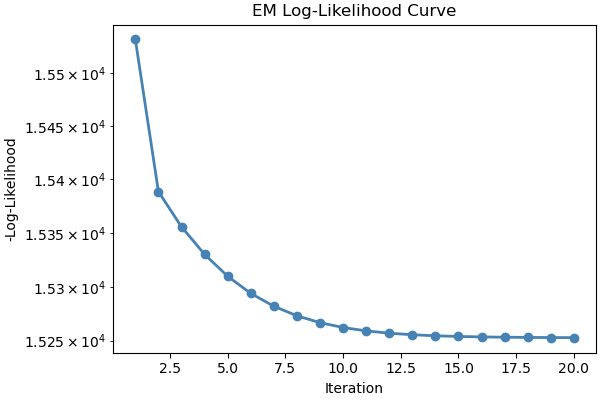

In [11]:
# plot cellsweep likelihood over epochs
if os.path.exists(adata_log_path):
    cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=adata_log_path, show=True)

In [12]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

KeyboardInterrupt: 

In [ ]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_2          1   Type_0     False          0.008826  10769.844446   
Cell_13         2   Type_1     False          0.013309   7020.196873   
Cell_36         3   Type_2     False          0.021265   5301.430253   
Cell_41         2   Type_1     False          0.009647   9654.391176   
Cell_47         2   Type_1     False          0.009074   8863.274881   
...           ...      ...       ...               ...           ...   
Cell_7970       2   Type_1     False          0.008577   8621.253264   
Cell_7973       3   Type_2     False          0.006243  12430.731439   
Cell_7981       2   Type_1     False          0.012129   6292.578014   
Cell_7982       4   Type_3     False          0.010759   8412.954624   
Cell_7995       2   Type_1     False          0.005744  13260.444688   

           cell_ambient_fraction  alpha_hat  z_hat  
Cell_2                       0.9   0.062395      1  
Cell_13                      

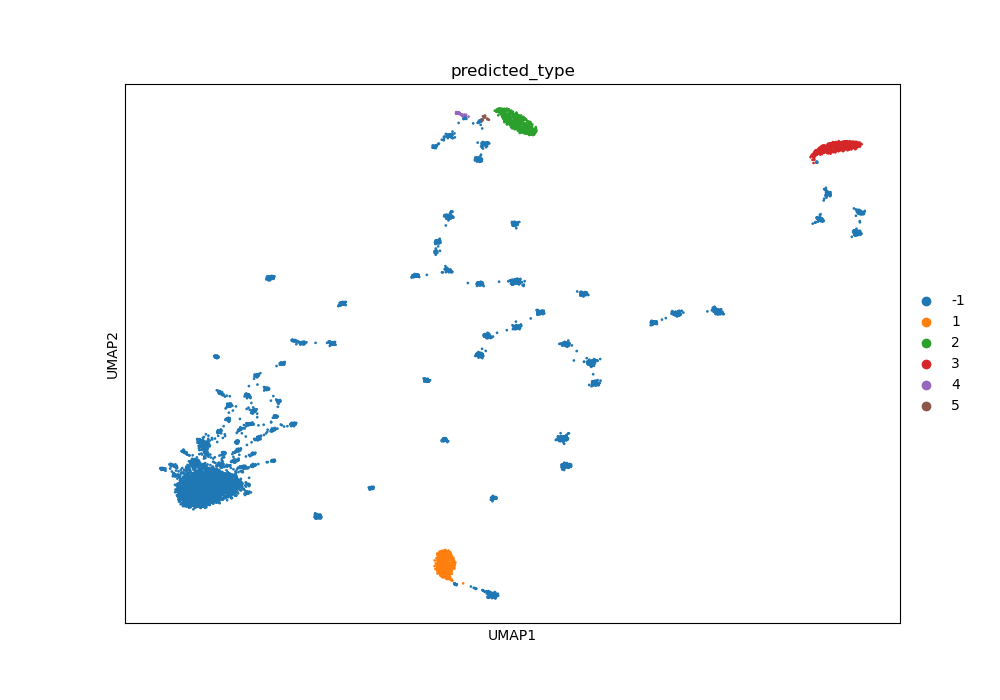

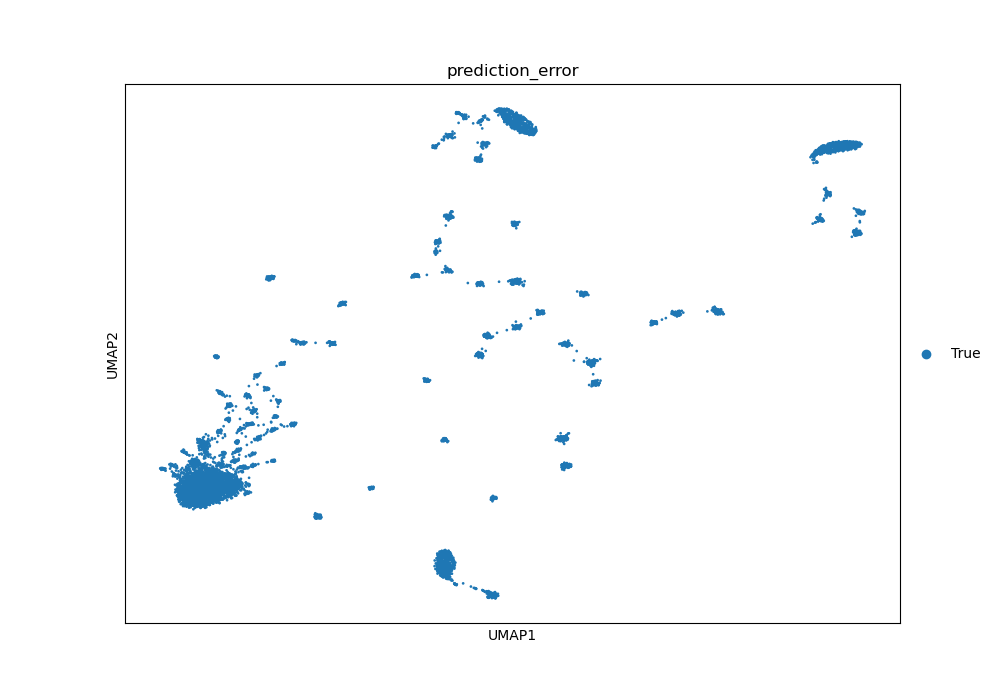

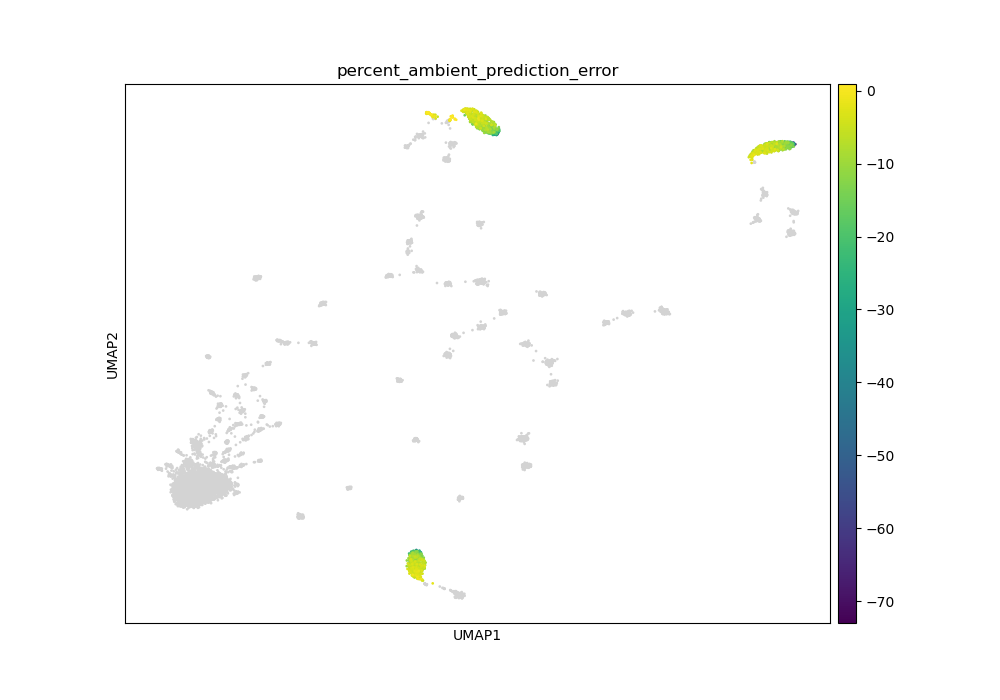

In [ ]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'].astype(int) == denoised_data.obs['cellid'].astype(int))

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)

In [ ]:
data

AnnData object with n_obs × n_vars = 8000 × 10000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size', 'log_ambient', 'percent_ambient_prediction_error', 'predicted_type', 'prediction_error'
    var: 'ambient_profile', 'is_marker'
    uns: 'simulation_params', 'marker_sets', 'type_profiles', 'pca', 'neighbors', 'umap', 'celltype_colors', 'predicted_type_colors', 'prediction_error_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'noise', 'real'
    obsp: 'distances', 'connectivities'

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


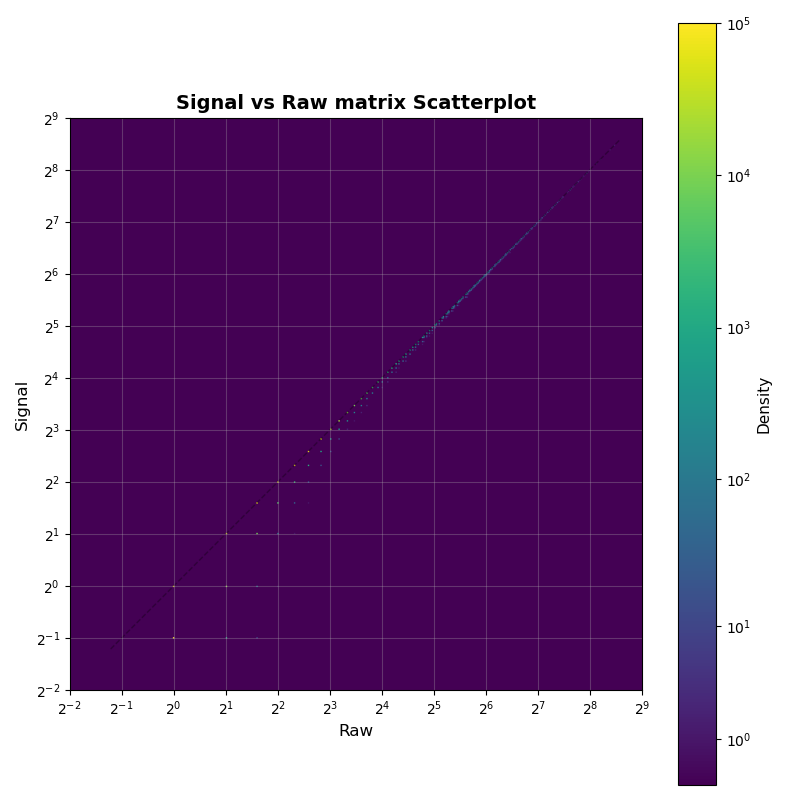

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


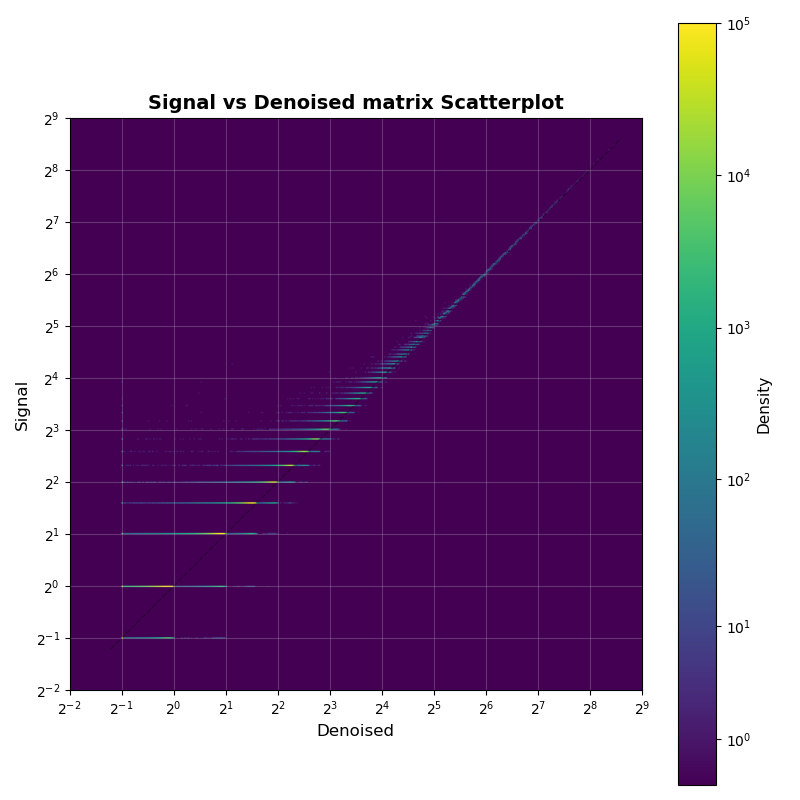

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


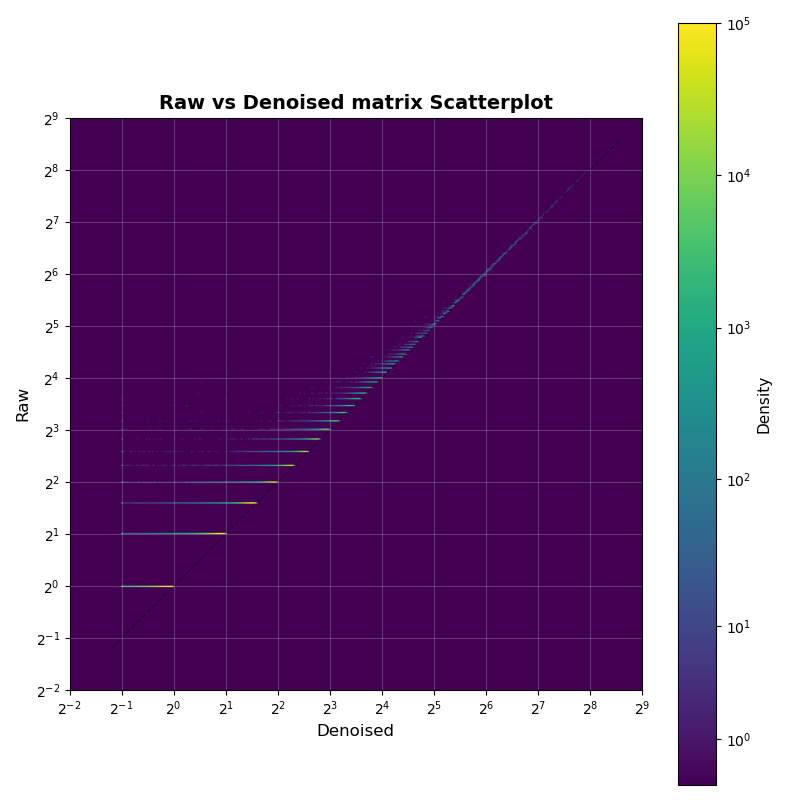

In [ ]:
real_data = data.copy()
real_data.X = real_data.layers['real'].copy()
cs_utils.plot_matrix_scatterplot(data, real_data, x_axis="Raw", y_axis="Signal", point_type="matrix", density_type="scatter_with_density", scale="log")
cs_utils.plot_matrix_scatterplot(denoised_data, real_data, x_axis="Denoised", y_axis="Signal", point_type="matrix", density_type="scatter_with_density", scale="log")
cs_utils.plot_matrix_scatterplot(denoised_data, data, x_axis="Denoised", y_axis="Raw", point_type="matrix", density_type="scatter_with_density", scale="log")